In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from venn import venn
from scipy.stats import zscore, variation
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import normalize, scale, MinMaxScaler
import matplotlib as mpl
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
def accessBedData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3])
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes



def accessAnnBedData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,38,39,40,41,42], header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def accessAnnBedData2(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,38,39,40,41,42,43,44,45,46], header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def accessAnnBedData3(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,7, 8,9,10,11], header=None)
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes



def accessData(list_files, path, list_labels):
    """opens each file and stores in dictionary with key a label"""
    #create empty dictionary to store the dataframes
    dic_dataframes = {}
    #iterate to get the file names
    #make a counter to access the correct label
    count = 0
    for file in list_files:
        #open each file
        data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3])
        #add the dataframe as an element of a dictionary with key the filename
        dic_dataframes[list_labels[count]] = data_frame
        count = count + 1
    return dic_dataframes

def normalize(dic_data, dic_total, scaling_value):
    """Normalize to desired value (mean, median...)
    1. divide by the total counts in each column
    2. multiply by scaling value"""
    #make a counter for the smaple number to select the scaling_value position
    count = 0
    #make a dictionary to store the normalized datasets
    dic_normal = {}
    #Get each dataframe
    for key in dic_data:
        #divide each section by the total of the section
        data_frame_normal_s1 = dic_data[key].divide(dic_total[key], axis='columns')
        #multiply by the scaling value
        data_frame_normal = data_frame_normal_s1.multiply(scaling_value)
        count = count + 1
        #save the dataframe to the dictionary
        dic_normal[key] = data_frame_normal
    return dic_normal


def saveCSV(dic_data, path, label):
    """Save dataframes inside dictionary to csv files"""
    for key in dic_data:
        dic_data[key].to_csv(path+key+label+'.bed', sep='\t', header=True)
    return print('Files saved')


def zscores(data):
    """Calculates de z scores for each gene individually"""
    #create a dataframe to store the zscores
    df_zscore = pd.DataFrame(columns = data.columns, index = data.index)
    #calculate z scores for each gene
    #for that we need to get the info from every row independently and then get the z score
    for index in data.index.values:
        #transform the series into list, then to np.array and apply z score funtion from scipy.stats
        #and save it to the Zscore df
        data_gene = np.array(list(data.loc[index]))
        df_zscore.loc[index] = zscore(data_gene.astype(float))
    #save the df_zscores to the dictionary
    data_zscores = df_zscore.astype(float)
    return data_zscores


def scaledZscores(data):
    """Calculates de scaled z scores for each gene individually.
    Normalize the Z score to scaled Z score (-1 to 1)"""
    #create a dataframe to store the zscores
    df_scaled_zscore = pd.DataFrame(columns = data.columns, index = data.index)
    #calculate z scores for each gene
    #for that we need to get the info from every row independently and then get the z score
    for index in data.index.values:
        ## 1.convert the column value of the dataframe to floats
        float_array = data.loc[index].values.astype(float)
        # Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.
        float_array = float_array.reshape(-1, 1)
        # 2. create a min max processing object
        min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
        scaled_array = min_max_scaler.fit_transform(float_array)
        # 3. convert the scaled array to dataframe. First reshape the array to the original shape
        scaled_array = scaled_array.reshape(len(data.columns.values),)
        df_scaled_zscore.loc[index] = scaled_array
    #save the df_zscores to the dictionary
    #Use astype(float) to ensure the values are numbers for correct plotting
    data_scaled_zscores = df_scaled_zscore.astype(float)
    return data_scaled_zscores


## Anna's formulas for hierarchical clustering
def hierarchicalClustering(df, cth = 100, plot = False, method = 'ward', metric = 'euclidean', nolabels = 'True', leaf_colors = []):
    """performs hierarchical clustering using linkage and dendogram functions from scipy.cluster.hierarchy package"""
    if len(leaf_colors) > 0:
        hierarchy.set_link_color_palette(leaf_colors)
    df = df.replace(np.nan,0)
    Z = linkage(df, method=method, metric = metric)
    dg = dendrogram(Z, no_labels=nolabels, color_threshold=cth, no_plot = np.invert(plot))
    plt.show()
    return Z, dg

def getClusterByColor(dg, labels):
    """given a dendogram and labels, it groups labels by colors in the dendogram (i.e. clusters)"""
    kk = []
    ii = 0
    cluster = 0
    color = dg['color_list'][0]
    clusters = {cluster: []}
    for i in range(len(dg['icoord'])):
        v = dg['icoord'][i]
        for j in [0,2]:
            vj = int(round((v[j]-5.)/10))
            if (v[j]-5.)/10 == vj and vj not in kk:
                kk.append(vj)
                if dg['color_list'][i] == color:
                    clusters[cluster].append(labels[dg['leaves'][vj]])
                else:
                    color = dg['color_list'][i]
                    cluster += 1
                    clusters[cluster] = [labels[dg['leaves'][vj]]]
    return clusters

def plotHeatmap(dic_data, dg, clusters, figsize, type_data, reorganize = False, new_index_order = []):
    """Use the combined clustering to plot the indivudal heatmaps for each sample"""
    #access each dictionary and count the number of samples
    keys = []
    for key in dic_data:
        keys.append(key)      
    #check the number of samples to provide the width ratios
    ratios = [0.5]
    for element in range(len(keys)):
        if element < len(keys)-1:
            ratios.append(3)
        if element == len(keys)-1:
            ratios.append(4)
    # plot multiple plots with plt.sublots. axs is a list of all the subplots. Plot as many plots as samples plus 
    # one for the cluster label
    fig, axs = plt.subplots(nrows = 1, ncols = len(keys)+1, sharey='row', gridspec_kw={'width_ratios': ratios}, figsize = figsize);
    #make a count to access the correct plot
    count = 0
    for key in dic_data:
        if reorganize == False:
            #use dg['leaves'] indexes to organize the data to plot
            data_plot = dic_data[key].loc[dic_data[key].index[dg['leaves']]]
        if reorganize == True:
            data_plot = dic_data[key].reindex(index = new_index_order)
        # to plot I use ax.imshow
        im = axs[count+1].imshow(data_plot, aspect='auto', interpolation='none', cmap='viridis')
        # Hide grid lines
        axs[count+1].grid(False)
        # add labels
        axs[count+1].set_title(key)
        #remove ticks on the y axis
        axs[count+1].tick_params(top=False, bottom=True, left=False, right=False, labelsize=8)
        axs[count+1].set_xticks(list(np.arange(0,len(dic_data[key].columns),1)), list(dic_data[key].columns))
        #add 1 to the count to go to next sample
        count = count + 1
        
    #create the colour bar and label it, we use the last image (im)
    #cax = divider.append_axes('left', size='5%', pad=0.05)
    cb = fig.colorbar(im, orientation='vertical', shrink = 0.3)
    cb.set_label(type_data)

    # Make a big plot in order to craete shared axis labels
    # add a big axes, hide frame
    fig.add_subplot(111, frameon=False)
    # hide tick and tick label of the big axes
    plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    plt.grid(False)
    plt.xlabel("Sections A-P")

    #Introduce the cluster bar
    #make the variable bottom to 0, which indicates were the cluster starts
    bottom = 0
    for cluster in clusters:
        if int(cluster) < len(clusters)-1: 
            #get the height of the cluster
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster labels
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')
            #add the length of the current cluster to the bottom variable for the next cluster start
            bottom = bottom + len(clusters[cluster])

        #I add -1 to the last bottom, otherwise the plot gets out of the grid
        if int(cluster) == len(clusters)-1:
            height = len(clusters[cluster])
            axs[0].bar(-0.5, height = height, bottom=bottom-0.5, width=0.2, align='center')
            #add cluster label
            axs[0].text(-0.5, bottom-0.5+height/2, str(int(cluster)+1), ha='center', va='center')

    #axs[0].set_ylim(0,bottom)  

    #remove ticks and plot frame from the cluster bar
    axs[0].tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
    axs[0].axis('off')

    plt.show()



    
def ClusterGeneNames(data, clusters, dg, file_name):
    """Creates a txt file that contains the gene ids of each cluster to use for GO search"""
    #create the file
    #We declared the variable f to open a file . Open takes 2 arguments, the file that we want 
    #to open and a string that represents the kinds of permission or operation we want to do on the file
    #Here, we used "w" letter in our argument, which indicates write and will create a file if it does 
    #not exist in library
    #Plus sign indicates both read and write.
    f = open(file_name,"w+")
    #change the index order of the data in the heatmap
    data = data.index[dg['leaves']]
    #access the gene info of each cluster
    start = 0
    end = 0
    dic_genes={}
    for key in clusters:
        #writte the cluster name
        #The output we want to iterate in the file is "Cluster ", which we declare with write function and 
        #then percent d (displays integer)
        #So basically we are putting in the line number that we are writing (key + 1), then putting it in a carriage 
        #return and a new line character
        f.write('\nCluster %d\r\n' % (int(key)+1))
        #go through each index to substract the gene id and write it on the file
        end = end + len(clusters[key])
        list_g=[]
        for element in data[start:end]:
            #split the index and save the gene id and new line
            info = element[-1].split('_')
            f.write(str(info[1]) + '\n')
            list_g.append(str(info[1]))
        dic_genes[key]=list_g
        start = start + len(clusters[key])
    #close the file when done
    f.close()
    
    return dic_genes


def plotMeanCluster(dic_data, list_clusters, xlabel = 'Sections A-P', ylabel = 'Counts'):
    """Plot the specified cluster data"""
    #get cluster data and plot
    for key in dic_data:
        data_frame = dic_data[key]
        #find the column values for the cluster of interest
        for cluster in list_clusters:
            cluster_data = data_frame.loc[str(cluster)]
            #plot the data
            cluster_data.plot(label = cluster+1);
        plt.xlabel(xlabel,fontsize=15);
        plt.ylabel(ylabel,fontsize=15);
        plt.legend(fontsize=15, frameon=False);
        plt.title(key,fontsize=15)
        plt.xticks(fontsize=15)
        plt.yticks(fontsize=15)
        plt.show();
    
    return plt

    #############################################################
    #############################################################
    #############################################################


# Explore DMRs all, TSS and gene bodies

In [34]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path=''
file_names = ['M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_p0.05_MvsF_TSS3kb_v2.bed', 'M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_p0.05_MvsF_genes_v2.bed']
labels = ['DMRs_tss3k', 'DMRs_genebodies']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data = accessAnnBedData(file_names, path, labels)
data['DMRs_genebodies'] = data['DMRs_genebodies'].drop(index=["X", "Y"])
data['DMRs_tss3k'] = data['DMRs_tss3k'].drop(index=["X", "Y"])
data['DMRs_genebodies']


/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:27: DtypeWarning: Columns (0,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,38,39,40,41,42], header=None)
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:27: DtypeWarning: Columns (0,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,38,39,40,41,42], header=None)
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3074354774.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data['DMRs_genebodies'] = data['DMRs_genebodies'].drop(index=["X", "Y"])
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3074354774.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may im

4   \
0 1         2         3  38 39        40        41 42                                                    
1 3214826   3215825   1  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding      0.000000   
  3275826   3276825   23 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding      0.000000   
  3333826   3334825   4  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding      0.000000   
  3343826   3344825   11 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding      0.000000   
  3384826   3385825   6  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding      0.000000   
...                                                                                                ...   
9 124138380 124139379 1  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding      0.000000   
  124139380 124140379 7  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding      0.000000   
  124437380 124438379 19 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding   0.000000   
  124439380 124440379 16 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding  94.112099   
  124475380 124476379 14 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding  44.175067   

                                                                                                     5   \
0 1         2         3  38 39        40        41 42                                                     
1 3214826   3215825   1  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding       0.000000   
  3275826   3276825   23 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding       0.000000   
  3333826   3334825   4  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding       0.000000   
  3343826   3344825   11 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding       0.000000   
  3384826   3385825   6  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding       0.000000   
...                                                                                                 ...   
9 124138380 124139379 1  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding       0.000000   
  124139380 124140379 7  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding       0.000000   
  124437380 124438379 19 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding    0.000000   
  124439380 124440379 16 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding  817.315770   
  124475380 124476379 14 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding   35.119037   

                                                                                                      6   \
0 1         2         3  38 39        40        41 42                                                      
1 3214826   3215825   1  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding        0.000000   
  3275826   3276825   23 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding        0.000000   
  3333826   3334825   4  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding        0.000000   
  3343826   3344825   11 1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding        0.000000   
  3384826   3385825   6  1  3205901   3671498   -  ENSMUSG00000051951_Xkr4_ProteinCoding        2.402411   
...                                                                                                  ...   
9 124138380 124139379 1  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding        0.000000   
  124139380 124140379 7  9  124121543 124147699 +  ENSMUSG00000079227_Ccr5_ProteinCoding        0.000000   
  124437380 124438379 19 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding     0.000000   
  124439380 124440379 16 9  124422622 124476898 -  ENSMUSG00000093803_Ppp2r3d_ProteinCoding  1013.817357   
  124475380 124476379 14 9  12442

In [35]:
#rename sections by the same id as usplit DMRs file because
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path=''
file_names = ['M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_p0.05_MvsF.bed']
labels = ['DMRs_all']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_all = accessBedData(file_names, path, labels)
data_all['DMRs_all']


/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3])


M1_s10    M1_s11     M1_s12     M1_s13  \
chr start   end     Lpnp1                                              
1   3052826 3053825 16      0.000000  0.000000   0.000000   1.978885   
    3235826 3236825 3       0.000000  0.000000   0.000000   0.000000   
    3418826 3419825 4       0.000000  7.981599   0.000000   0.000000   
    4523826 4524825 5       0.000000  0.000000   1.201205   0.000000   
    4590826 4591825 14     38.413102  0.000000  21.621697  16.820524   
...                              ...       ...        ...        ...   
Y   2360510 2361509 18      0.000000  0.000000   0.000000   0.000000   
    3843510 3844509 13      0.000000  0.000000   0.000000   0.000000   
    4247510 4248509 8       0.000000  0.000000   0.000000   0.000000   
    4248510 4249509 10      0.000000  0.000000   0.000000   0.000000   
    9624510 9625509 9       0.000000  0.000000   0.000000   0.000000   

                              M1_s24     M1_s25    M1_s27     M1_s35  \
chr start   end     Lpnp1                                              
1   3052826 3053825 16      0.000000   0.000000  0.000000   0.000000   
    3235826 3236825 3       0.000000   0.000000  0.000000   0.000000   
    3418826 3419825 4       0.000000   0.000000  0.000000   0.000000   
    4523826 4524825 5       0.000000   0.000000  0.000000   0.000000   
    4590826 4591825 14     42.156576  80.196818  7.130716  56.560629   
...                              ...        ...       ...        ...   
Y   2360510 2361509 18      0.000000   0.000000  0.000000   0.000000   
    3843510 3844509 13      0.000000   0.000000  0.000000   0.000000   
    4247510 4248509 8       0.000000   0.000000  0.000000   0.000000   
    4248510 4249509 10      0.000000   0.000000  0.000000   0.000000   
    9624510 9625509 9       0.000000   0.000000  0.000000   0.000000   

                             M1_s36     M1_s38  ...      M3_s3      M3_s4  \
chr start   end     Lpnp1                       ...                         
1   3052826 3053825 16     0.000000   0.000000  ...  15.140470   1.893172   
    3235826 3236825 3      0.000000   0.000000  ...   1.682274   5.679515   
    3418826 3419825 4      0.000000   1.919661  ...  11.775921  15.145373   
    4523826 4524825 5      0.000000   0.000000  ...   4.205686   0.946586   
    4590826 4591825 14     3.263199  17.276953  ...  74.020077  61.528077   
...                             ...        ...  ...        ...        ...   
Y   2360510 2361509 18     0.000000   0.000000  ...  21.869568  20.824888   
    3843510 3844509 13     0.000000   0.000000  ...  55.515058  30.290746   
    4247510 4248509 8      0.000000   0.000000  ...  41.215725  53.955390   
    4248510 4249509 10     0.000000   0.000000  ...  29.439804  44.489532   
    9624510 9625509 9      0.000000   0.000000  ...  43.739137  47.329290   

                               M3_s17      M3_s18      M3_s19     M3_s20  \
chr start   end     Lpnp1                                                  
1   3052826 3053825 16      14.181450   15.850242   12.403690  12.979227   
    3235826 3236825 3        4.171015    6.163983    1.653825   8.652818   
    3418826 3419825 4       21.689276   12.327966    4.134563   6.056973   
    4523826 4524825 5        8.342029    7.044552    8.269127   8.652818   
    4590826 4591825 14     100.938554  104.787713  100.883346  71.818392   
...                               ...         ...         ...        ...   
Y   2360510 2361509 18      22.523479   27.297639   16.538253  30.284864   
    3843510 3844509 13      23.357682   50.192434   41.345633  38.072401   
    4247510 4248509 8       37.539132   42.267313   42.172546  52.782192   
    4248510 4249509 10      25.860291   25.536501   25.634293  25.093173   
    9624510 9625509 9       44.212755   46.670158   37.211070  38.072401   

                               M3_s33     M3_s34     M3_s35     M3_s36  
chr start   end     Lpnp1                                               
1   3052826 3053825

In [36]:
for index in data['DMRs_tss3k'].index:
    if 'H19' in index[-1]:
        print(index[-1])

ENSMUSG00000112832_4930484H19Rik_lincRNA
ENSMUSG00000112832_4930484H19Rik_lincRNA
ENSMUSG00000086262_A930031H19Rik_lincRNA
ENSMUSG00000108530_4930429H19Rik_lincRNA
ENSMUSG00000108530_4930429H19Rik_lincRNA
ENSMUSG00000000031_H19_lincRNA


In [37]:
data['DMRs_genebodies'].columns=data_all['DMRs_all'].columns
data['DMRs_tss3k'].columns=data_all['DMRs_all'].columns
data['DMRs_tss3k']

M1_s10  \
0 1         2         3  38 39        40        41 42                                                           
1 3985826   3986825   14 1  3986115   3989215   -  ENSMUSG00000102343_Gm37381_lincRNA                     0.0   
  4607826   4608825   4  1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene          0.0   
  4609826   4610825   11 1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene          0.0   
  4803826   4804825   2  1  4804788   4807888   +  ENSMUSG00000025903_Lypla1_ProteinCoding                0.0   
  4882826   4883825   3  1  4880551   4883651   -  ENSMUSG00000062588_Gm6104_ProcessedPseudogene          0.0   
...                                                                                                       ...   
9 123215380 123216379 38 9  123215938 123219038 -  ENSMUSG00000035498_Cdcp1_ProteinCoding                 0.0   
  123303380 123304379 10 9  123304084 123307184 +  ENSMUSG00000111371_Gm47162_lincRNA                     0.0   
  123317380 123318379 5  9  123317898 123320998 -  ENSMUSG00000058492_Scp2.ps2_TranscribedUnproces...     0.0   
  123640380 123641379 4  9  123640166 123643266 +  ENSMUSG00000110735_Gm47173_TEC                         0.0   
  123793380 123794379 3  9  123791189 123794289 -  ENSMUSG00000091661_Gm17021_SenseOverlapping            0.0   

                                                                                                          M1_s11  \
0 1         2         3  38 39        40        41 42                                                              
1 3985826   3986825   14 1  3986115   3989215   -  ENSMUSG00000102343_Gm37381_lincRNA                  38.311677   
  4607826   4608825   4  1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene        0.000000   
  4609826   4610825   11 1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene        0.000000   
  4803826   4804825   2  1  4804788   4807888   +  ENSMUSG00000025903_Lypla1_ProteinCoding              0.000000   
  4882826   4883825   3  1  4880551   4883651   -  ENSMUSG00000062588_Gm6104_ProcessedPseudogene        0.000000   
...                                                                                                          ...   
9 123215380 123216379 38 9  123215938 123219038 -  ENSMUSG00000035498_Cdcp1_ProteinCoding               9.577919   
  123303380 123304379 10 9  123304084 123307184 +  ENSMUSG00000111371_Gm47162_lincRNA                  47.889596   
  123317380 123318379 5  9  123317898 123320998 -  ENSMUSG00000058492_Scp2.ps2_TranscribedUnproces...   0.000000   
  123640380 123641379 4  9  123640166 123643266 +  ENSMUSG00000110735_Gm47173_TEC                       0.000000   
  123793380 123794379 3  9  123791189 123794289 -  ENSMUSG00000091661_Gm17021_SenseOverlapping          0.000000   

                                                                                                          M1_s12  \
0 1         2         3  38 39        40        41 42                                                              
1 3985826   3986825   14 1  3986115   3989215   -  ENSMUSG00000102343_Gm37381_lincRNA                  64.865092   
  4607826   4608825   4  1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene        0.000000   
  4609826   4610825   11 1  4607471   4610571   +  ENSMUSG00000102735_Gm7369_ProcessedPseudogene        0.000000   
  4803826   4804825   2  1  4804788   4807888   +  ENSMUSG00000025903_Lypla1_ProteinCoding              0.000000   
  4882826   4883825   3  1  4880551   4883651   -  ENSMUSG00000062588_Gm6104_ProcessedPseudogene        0.000000   
...                                                                                                          ...   
9 123215380 123216379 38 9  123215938 123219038 -  ENSMUSG00000035498_Cdcp1_ProteinCoding              91.291610   
  123303380 123304379 10 9  123304084 123307184 +  ENSMUSG00000111371_Gm47162_li

In [38]:
#rename sections by the same id as usplit DMRs file because
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path=''
file_names = ['M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_pval_MvsF_TSS3kb_v2.bed', 'M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_pval_MvsF_genes_v2.bed']
labels = ['DMRs_tss3k', 'DMRs_genebodies']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_p = accessAnnBedData3(file_names, path, labels)
data_p['DMRs_tss3k']


/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:57: DtypeWarning: Columns (0,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,7, 8,9,10,11], header=None)
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:57: DtypeWarning: Columns (0,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,7, 8,9,10,11], header=None)


4  \
0 1        2        3 7 8        9        10 11                                                           
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.000000   
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              1.650577   
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              1.288144   
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              2.743549   
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                  0.000000   
...                                                                                                 ...   
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  0.000000   
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  0.000000   
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                0.000000   
  10624510 10625509 3 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                0.000000   
  10626510 10627509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                0.000000   

                                                                                                      5  \
0 1        2        3 7 8        9        10 11                                                           
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              1.000000   
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.186394   
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.338801   
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.182452   
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                  1.000000   
...                                                                                                 ...   
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  1.000000   
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  1.000000   
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                1.000000   
  10624510 10625509 3 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                1.000000   
  10626510 10627509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                1.000000   

                                                                                                      6  
0 1        2        3 7 8        9        10 11                                                          
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              1.000000  
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.570353  
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.657197  
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC              0.565483  
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                  1.000000  
...                                                                                                 ...  
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  1.000000  
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene  1.000000  
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                1.000000  
  10624510 10625509 3 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                1.000000  
  10626510 10627509 1 Y 10623743 10626843 +  E

In [39]:
data_p['DMRs_genebodies'].columns=['Log2FC_MvsF', 'p_val_MvsF', 'adj_p_val_MvsF']
data_p['DMRs_tss3k'].columns=['Log2FC_MvsF', 'p_val_MvsF', 'adj_p_val_MvsF']
data_p['DMRs_tss3k']

Log2FC_MvsF  \
0 1        2        3 7 8        9        10 11                                                              
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                 0.000000   
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                 1.650577   
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                 1.288144   
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                 2.743549   
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                     0.000000   
...                                                                                                    ...   
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene     0.000000   
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene     0.000000   
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                   0.000000   
  10624510 10625509 3 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                   0.000000   
  10626510 10627509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                   0.000000   

                                                                                               p_val_MvsF  \
0 1        2        3 7 8        9        10 11                                                             
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                1.000000   
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                0.186394   
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                0.338801   
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                0.182452   
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                    1.000000   
...                                                                                                   ...   
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene    1.000000   
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene    1.000000   
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                  1.000000   
  10624510 10625509 3 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                  1.000000   
  10626510 10627509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                  1.000000   

                                                                                               adj_p_val_MvsF  
0 1        2        3 7 8        9        10 11                                                                
1 3069826  3070825  5 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                    1.000000  
  3070826  3071825  1 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                    0.570353  
  3071826  3072825  3 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                    0.657197  
  3072826  3073825  4 1 3070253  3073353  +  ENSMUSG00000102693_4933401J01Rik_TEC                    0.565483  
  3098826  3099825  5 1 3099016  3102116  +  ENSMUSG00000064842_Gm26206_snRNA                        1.000000  
...                                                                                                       ...  
Y 10613510 10614509 2 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene        1.000000  
  10615510 10616509 4 Y 10613361 10616461 +  ENSMUSG00000118422_Gm21900_UnprocessedPseudogene        1.000000  
  10623510 10624509 1 Y 10623743 10626843 +  ENSMUSG00000100369_Gm29527_lincRNA                      1.000000  
  10624510 106

In [40]:
print(data['DMRs_tss3k'].index.names)
print(data_p['DMRs_tss3k'].index.names)

[0, 1, 2, 3, 38, 39, 40, 41, 42]
[0, 1, 2, 3, 7, 8, 9, 10, 11]


In [41]:
#merge all CpGs from same gene
data_merged={}
data_p_merged={}
data_merged['DMRs_tss3k']=data['DMRs_tss3k'].groupby(level=42).sum(numeric_only=True)
data_merged['DMRs_genebodies']=data['DMRs_genebodies'].groupby(level=42).sum(numeric_only=True)
data_p_merged['DMRs_tss3k']=data_p['DMRs_tss3k'].groupby(level=11).mean(numeric_only=True)
data_p_merged['DMRs_genebodies']=data_p['DMRs_genebodies'].groupby(level=11).mean(numeric_only=True)
data_merged['DMRs_tss3k']

,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
42,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,0.000000,57.467515,66.066297,134.564193,94.852295,120.745771,17.826791,94.630283,64.176237,112.300194,...,23.551843,35.970260,16.684058,20.253087,53.749323,22.497328,35.515982,36.863312,17.267809,39.453243
ENSMUSG00000000031_H19_lincRNA,34.571792,98.971832,140.541032,308.706091,251.023246,143.272967,188.072643,346.977706,316.530255,263.953448,...,104.301018,118.323225,50.886378,57.236986,81.037442,121.139457,85.602622,106.993514,88.156709,94.302874
ENSMUSG00000000049_Apoh_ProteinCoding,0.000000,0.000000,7.207232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.919661,...,8.411372,1.893172,11.678841,18.491949,17.365166,1.730564,34.605315,17.982103,18.176641,4.811371
ENSMUSG00000000078_Klf6_ProteinCoding,86.429479,113.338710,111.712102,17.809967,45.988992,141.470792,124.787536,36.981950,17.403725,33.594075,...,13.458196,0.000000,21.689276,7.925121,14.057515,21.632046,19.123990,5.394631,4.544160,8.660468
ENSMUSG00000000120_Ngfr_ProteinCoding,0.000000,6.385279,0.000000,0.000000,7.664832,108.130541,0.000000,0.000000,0.000000,5.758984,...,33.645490,20.824888,24.191885,29.058777,28.115031,54.512755,21.855989,26.973155,11.814817,20.207759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118647_AL670227.1_UnitaryPseudogene,0.000000,0.000000,0.000000,32.651606,33.533640,0.000000,1.782679,16.315566,1.087733,0.959831,...,26.916392,10.412444,32.533914,22.894794,19.845904,10.383382,26.409320,35.964207,31.809122,34.641872
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,0.000000,0.000000,3.603616,0.989443,41.198472,0.000000,0.000000,10.877044,0.000000,0.000000,...,42.897999,37.863432,20.020870,26.417070,57.883887,26.823737,41.890645,36.863312,16.358977,32.717324
ENSMUSG00000118652_AL645799.1_lincRNA,161.335028,247.429579,112.913307,93.997047,221.322022,273.029617,191.638002,143.576982,96.808222,110.380533,...,46.262548,90.872237,45.881161,36.103330,52.095498,45.859937,59.193303,37.762417,33.626786,26.943678


In [42]:
data_p_merged['DMRs_tss3k']

,Log2FC_MvsF,p_val_MvsF,adj_p_val_MvsF
11,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,-0.925187,0.288825,0.517741
ENSMUSG00000000003_Pbsn_ProteinCoding,-1.428362,0.602883,0.852826
ENSMUSG00000000028_Cdc45_ProteinCoding,-0.444876,0.669023,0.888778
ENSMUSG00000000031_H19_lincRNA,-0.293092,0.152234,0.375519
ENSMUSG00000000037_Scml2_ProteinCoding,0.931234,0.094772,0.449923
...,...,...,...
ENSMUSG00000118655_AC156032.1_ProcessedTranscript,0.331855,0.134112,0.322545
ENSMUSG00000118656_BX681418.1_UnitaryPseudogene,-0.659896,0.825670,0.916598
ENSMUSG00000118657_AL606917.1_UnprocessedPseudogene,0.158705,0.472839,0.684469


In [43]:
for index in data_merged['DMRs_tss3k'].index:
    if 'Gsk3a' in index:
        print(data_merged['DMRs_tss3k'].loc[index])

M1_s10     0.000000
M1_s11     0.000000
M1_s12     0.000000
M1_s13     0.000000
M1_s24     0.000000
M1_s25     0.000000
M1_s27     0.000000
M1_s35     0.000000
M1_s36     0.000000
M1_s38    19.196614
M2_s8      0.000000
M2_s9      0.000000
M2_s10     0.000000
M2_s11     0.000000
M2_s22     0.000000
M2_s23     1.873902
M2_s24    10.094966
M2_s25     0.000000
M2_s36     0.000000
M2_s37     0.000000
M2_s38     0.000000
M2_s39     0.000000
M3_s1     22.555657
M3_s2     30.649285
M3_s3     24.392980
M3_s4     26.504402
M3_s17    21.689276
M3_s18    19.372518
M3_s19    19.845904
M3_s20    26.823737
M3_s33    24.587987
M3_s34    26.973155
M3_s35    29.082626
M3_s36    33.679598
Name: ENSMUSG00000057177_Gsk3a_ProteinCoding, dtype: float64


In [44]:
len(list(set(data_merged['DMRs_tss3k'].index) & set(data_merged['DMRs_genebodies'].index)))

9100

### 2) TSS3kb

In [82]:
data_male = data_merged['DMRs_tss3k'][['M3_s1', 'M3_s2', 'M3_s3', 'M3_s4', 'M3_s17', 'M3_s18','M3_s19', 'M3_s20',
    'M3_s33', 'M3_s34', 'M3_s35', 'M3_s36']]
data_male

,M3_s1,M3_s2,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
42,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,43.231676,68.728699,23.551843,35.970260,16.684058,20.253087,53.749323,22.497328,35.515982,36.863312,17.267809,39.453243
ENSMUSG00000000031_H19_lincRNA,90.222627,49.224609,104.301018,118.323225,50.886378,57.236986,81.037442,121.139457,85.602622,106.993514,88.156709,94.302874
ENSMUSG00000000049_Apoh_ProteinCoding,26.314933,13.002727,8.411372,1.893172,11.678841,18.491949,17.365166,1.730564,34.605315,17.982103,18.176641,4.811371
ENSMUSG00000000078_Klf6_ProteinCoding,8.458371,0.000000,13.458196,0.000000,21.689276,7.925121,14.057515,21.632046,19.123990,5.394631,4.544160,8.660468
ENSMUSG00000000120_Ngfr_ProteinCoding,16.916743,37.150648,33.645490,20.824888,24.191885,29.058777,28.115031,54.512755,21.855989,26.973155,11.814817,20.207759
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118647_AL670227.1_UnitaryPseudogene,17.856562,29.720518,26.916392,10.412444,32.533914,22.894794,19.845904,10.383382,26.409320,35.964207,31.809122,34.641872
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,16.916743,30.649285,42.897999,37.863432,20.020870,26.417070,57.883887,26.823737,41.890645,36.863312,16.358977,32.717324
ENSMUSG00000118652_AL645799.1_lincRNA,49.810409,54.797206,46.262548,90.872237,45.881161,36.103330,52.095498,45.859937,59.193303,37.762417,33.626786,26.943678


In [83]:
data_female = data_merged['DMRs_tss3k'][['M1_s10', 'M1_s11', 'M1_s12', 'M1_s13','M1_s24', 'M1_s25', 'M1_s27','M1_s35', 'M1_s36', 'M1_s38',
    'M2_s8', 'M2_s9', 'M2_s10', 'M2_s11', 'M2_s22', 'M2_s23', 'M2_s24', 'M2_s25', 'M2_s36','M2_s37', 'M2_s38', 'M2_s39']]
data_female

,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M2_s10,M2_s11,M2_s22,M2_s23,M2_s24,M2_s25,M2_s36,M2_s37,M2_s38,M2_s39
42,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,0.000000,57.467515,66.066297,134.564193,94.852295,120.745771,17.826791,94.630283,64.176237,112.300194,...,80.038415,65.351579,72.976621,40.288903,92.873684,75.721821,66.204877,27.841353,76.225508,133.887905
ENSMUSG00000000031_H19_lincRNA,34.571792,98.971832,140.541032,308.706091,251.023246,143.272967,188.072643,346.977706,316.530255,263.953448,...,230.110442,216.628381,191.563631,184.579394,334.143363,270.705511,101.955511,225.824309,232.796823,385.202087
ENSMUSG00000000049_Apoh_ProteinCoding,0.000000,0.000000,7.207232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.919661,...,0.000000,0.000000,0.000000,0.000000,14.132952,0.000000,0.000000,4.124645,0.000000,0.000000
ENSMUSG00000000078_Klf6_ProteinCoding,86.429479,113.338710,111.712102,17.809967,45.988992,141.470792,124.787536,36.981950,17.403725,33.594075,...,30.014405,79.874152,7.094949,29.982440,50.474828,40.700479,9.268683,20.623225,15.451117,96.574882
ENSMUSG00000000120_Ngfr_ProteinCoding,0.000000,6.385279,0.000000,0.000000,7.664832,108.130541,0.000000,0.000000,0.000000,5.758984,...,14.006723,0.000000,2.027128,9.369512,0.000000,15.144364,0.000000,10.311612,20.601489,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118647_AL670227.1_UnitaryPseudogene,0.000000,0.000000,0.000000,32.651606,33.533640,0.000000,1.782679,16.315566,1.087733,0.959831,...,31.014886,8.471501,0.000000,4.684756,17.161442,22.716546,0.000000,15.467418,23.691712,4.389767
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,0.000000,0.000000,3.603616,0.989443,41.198472,0.000000,0.000000,10.877044,0.000000,0.000000,...,12.005762,0.000000,2.027128,9.369512,2.018993,0.000000,0.000000,1.031161,5.150372,0.000000
ENSMUSG00000118652_AL645799.1_lincRNA,161.335028,247.429579,112.913307,93.997047,221.322022,273.029617,191.638002,143.576982,96.808222,110.380533,...,93.044657,98.027368,94.261469,99.316831,157.481464,56.791366,156.243510,67.025480,45.323275,175.590695


In [84]:
data_clusters=pd.DataFrame(index=data_merged['DMRs_tss3k'].index)
data_clusters['male']=data_male.mean(axis=1)
data_clusters['female']=data_female.mean(axis=1)
data_clusters

,male,female
42,,
ENSMUSG00000000001_Gnai3_ProteinCoding,34.480552,72.035567
ENSMUSG00000000031_H19_lincRNA,87.285622,232.155294
ENSMUSG00000000049_Apoh_ProteinCoding,14.538680,1.749732
ENSMUSG00000000078_Klf6_ProteinCoding,10.411981,51.692663
ENSMUSG00000000120_Ngfr_ProteinCoding,27.105661,9.109565
...,...,...
ENSMUSG00000118647_AL670227.1_UnitaryPseudogene,24.949036,10.871737
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,32.275273,5.619104
ENSMUSG00000118652_AL645799.1_lincRNA,48.267376,134.702394


In [87]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
list_idx=[index.split('_')[1] for index in FC.index]
df_FC_TSS=pd.DataFrame({'Gene': list_idx, 'log2FC male vs female TSS': FC})
df_FC_TSS=df_FC_TSS.sort_values(by="log2FC male vs female TSS", ascending=True)
#df_FC_TSS['adj p_val'] = data_p['DMRs_tss3k']['adj_p_val_MvsF']
df_FC_TSS.to_excel('DMR male vs female TSS.xlsx')
df_FC_TSS[-10:]

,Gene,log2FC male vs female TSS
42,,
ENSMUSG00000115279_Gm49273_ProcessedPseudogene,Gm49273,9.391507
ENSMUSG00000110643_Gm18924_ProcessedPseudogene,Gm18924,9.442223
ENSMUSG00000084610_Gm25052_snRNA,Gm25052,9.527597
ENSMUSG00000070692_Rps12.ps10_ProcessedPseudogene,Rps12.ps10,9.667850
ENSMUSG00000114529_Gm4939_ProcessedPseudogene,Gm4939,9.696303
ENSMUSG00000098903_Gm28022_miRNA,Gm28022,9.912082
ENSMUSG00000083011_Gm12816_ProcessedPseudogene,Gm12816,10.060858
ENSMUSG00000100801_Gm15459_ProcessedPseudogene,Gm15459,10.410543
ENSMUSG00000094257_Ap3s1.ps2_ProcessedPseudogene,Ap3s1.ps2,10.565706


In [49]:
df_FC_TSS_filtered=df_FC_TSS[(df_FC_TSS['log2FC male vs female TSS']>= 2) | (df_FC_TSS['log2FC male vs female TSS']<= -2)]
data_merged_TSS_filtered=data_merged['DMRs_tss3k'].loc[df_FC_TSS_filtered.index]
data_merged_TSS_filtered

,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
42,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000030045_Mrpl19_ProteinCoding,124.842581,692.802821,400.001398,270.117829,206.950462,90.108784,326.230272,366.556385,356.776370,134.376301,...,1.682274,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.452992,2.886823
ENSMUSG00000083655_Gm12099_ProcessedPseudogene,0.000000,0.000000,0.000000,11.873311,8.622936,2.703264,114.091461,3.263113,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.880569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000034157_Cipc_ProteinCoding,0.000000,0.000000,1.201205,0.989443,11.497248,11.714142,8.022056,22.841793,0.000000,0.959831,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000078154_Gm12184_ProteinCoding,147.890442,0.000000,251.051928,41.556589,192.578902,8.109791,0.000000,28.280315,127.264742,67.188151,...,0.000000,0.000000,0.000000,7.044552,0.000000,0.000000,0.000000,5.394631,0.000000,2.886823
ENSMUSG00000040350_Trim7_ProteinCoding,147.890442,0.000000,251.051928,41.556589,192.578902,8.109791,0.000000,28.280315,127.264742,67.188151,...,0.000000,0.000000,0.000000,7.044552,0.000000,0.000000,0.000000,5.394631,0.000000,2.886823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000098903_Gm28022_miRNA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,95.048508,88.032479,85.922901,77.490073,97.575695,133.253402,108.369277,69.231098,94.518533,71.208293
ENSMUSG00000083011_Gm12816_ProcessedPseudogene,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.030116,97.498337,84.254495,133.846490,128.171464,186.035594,148.438590,46.753468,73.615396,61.585550
ENSMUSG00000100801_Gm15459_ProcessedPseudogene,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,125.329449,183.637645,101.772757,143.532749,135.613678,181.709185,131.135932,123.177407,102.698022,103.925616


In [50]:
keep=[]
for index in df_FC_TSS.index:
    if 'Myl' in index or 'Myh' in index or 'Tnn' in index or 'Atp' in index or 'Aldo' in index or 'Ttn' in index:
        keep.append(index)
        #print(df_FC_TSS.loc[index])
df_FC_TSS.loc[keep]

,Gene,log2FC male vs female TSS
42,,
ENSMUSG00000032412_Atp1b3_ProteinCoding,Atp1b3,-2.706335
ENSMUSG00000000563_Atp5pb_ProteinCoding,Atp5pb,-1.995796
ENSMUSG00000033379_Atp6v0b_ProteinCoding,Atp6v0b,-1.649349
ENSMUSG00000026418_Tnni1_ProteinCoding,Tnni1,-1.503170
ENSMUSG00000017300_Tnnc2_ProteinCoding,Tnnc2,-1.477951
ENSMUSG00000004285_Atp6v1f_ProteinCoding,Atp6v1f,-1.427221
ENSMUSG00000026463_Atp2b4_ProteinCoding,Atp2b4,-1.336435
ENSMUSG00000050856_Atp5k_ProteinCoding,Atp5k,-1.225543
ENSMUSG00000063129_Aldoart2_ProteinCoding,Aldoart2,-1.122127


In [51]:
keep=[]
for index in df_FC_TSS.index:
    if 'Myl' in index or 'Myh' in index or 'Myl' in index or 'Aldo' in index:
        keep.append(index)
        #print(df_FC_TSS.loc[index])
df_FC_TSS.loc[keep]

,Gene,log2FC male vs female TSS
42,,
ENSMUSG00000063129_Aldoart2_ProteinCoding,Aldoart2,-1.122127
ENSMUSG00000114515_Aldoa_ProteinCoding,Aldoa,-1.034357
ENSMUSG00000040752_Myh6_ProteinCoding,Myh6,-0.915645
ENSMUSG00000059741_Myl3_ProteinCoding,Myl3,1.170771
ENSMUSG00000061816_Myl1_ProteinCoding,Myl1,1.747657
ENSMUSG00000020900_Myh10_ProteinCoding,Myh10,1.999767
ENSMUSG00000024048_Myl12a_ProteinCoding,Myl12a,2.564354
ENSMUSG00000020908_Myh3_ProteinCoding,Myh3,2.575936


In [54]:
keep=[]
for index in df_FC_TSS.index:
    if 'Myl' in index or 'Myh' in index or 'Myl' in index or 'Aldo' in index  or 'Pkm' in index:
        keep.append(index)
        #print(df_FC_TSS.loc[index])
df_FC_TSS.loc[keep]


,Gene,log2FC male vs female TSS
42,,
ENSMUSG00000063129_Aldoart2_ProteinCoding,Aldoart2,-1.122127
ENSMUSG00000114515_Aldoa_ProteinCoding,Aldoa,-1.034357
ENSMUSG00000040752_Myh6_ProteinCoding,Myh6,-0.915645
ENSMUSG00000059741_Myl3_ProteinCoding,Myl3,1.170771
ENSMUSG00000061816_Myl1_ProteinCoding,Myl1,1.747657
ENSMUSG00000020900_Myh10_ProteinCoding,Myh10,1.999767
ENSMUSG00000024048_Myl12a_ProteinCoding,Myl12a,2.564354
ENSMUSG00000020908_Myh3_ProteinCoding,Myh3,2.575936


In [55]:
for index in df_FC_TSS.index:
    if 'Pkm' in index:
        print(df_FC_TSS.loc[index])

### 2) Gene bodies

In [88]:
data_male = data_merged['DMRs_genebodies'][['M3_s1', 'M3_s2', 'M3_s3', 'M3_s4', 'M3_s17', 'M3_s18','M3_s19', 'M3_s20',
    'M3_s33', 'M3_s34', 'M3_s35', 'M3_s36']]
data_male

,M3_s1,M3_s2,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
42,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,92.102265,52.010907,70.655528,60.581491,68.404640,68.684383,63.672275,51.051628,70.121297,25.174945,69.980068,97.189697
ENSMUSG00000000028_Cdc45_ProteinCoding,51.690047,34.364350,66.449842,58.688319,99.270148,89.818040,76.075965,137.579811,61.925301,93.506937,109.059846,57.736453
ENSMUSG00000000031_H19_lincRNA,73.305885,80.802660,59.720744,57.741734,44.212755,53.714710,47.960935,44.129373,69.210631,56.643625,39.079778,48.113711
ENSMUSG00000000049_Apoh_ProteinCoding,133.454303,44.580778,114.394665,106.964195,103.441162,160.263561,146.363542,112.486638,147.527924,145.655036,109.968678,113.548358
ENSMUSG00000000085_Scmh1_ProteinCoding,401.302727,288.846289,373.464936,390.939934,488.842913,454.373612,398.571906,440.428453,455.333097,317.384122,517.125436,359.890560
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118646_AC160405.1_ProteinCoding,70.486428,91.947854,89.160548,34.077089,75.078263,73.087228,67.806839,62.300292,62.835967,71.029308,79.068388,69.283744
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,10.338009,27.862986,29.439804,17.985130,16.684058,24.655932,45.480197,13.844509,31.873317,21.578524,9.088320,28.868227
ENSMUSG00000118652_AL645799.1_lincRNA,52.629866,37.150648,78.225764,48.275876,78.415075,59.878693,54.576236,76.144801,92.887952,77.323044,52.712259,91.416051


In [89]:
data_female = data_merged['DMRs_genebodies'][['M1_s10', 'M1_s11', 'M1_s12', 'M1_s13','M1_s24', 'M1_s25', 'M1_s27','M1_s35', 'M1_s36', 'M1_s38',
    'M2_s8', 'M2_s9', 'M2_s10', 'M2_s11', 'M2_s22', 'M2_s23', 'M2_s24', 'M2_s25', 'M2_s36','M2_s37', 'M2_s38', 'M2_s39']]
data_female

,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M2_s10,M2_s11,M2_s22,M2_s23,M2_s24,M2_s25,M2_s36,M2_s37,M2_s38,M2_s39
42,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000000001_Gnai3_ProteinCoding,0.000000,0.000000,1.201205,21.767737,22.994496,0.000000,0.000000,48.946698,18.491458,7.678646,...,28.013445,0.000000,48.651081,34.667196,8.075973,23.663069,27.806048,27.841353,60.774392,1.097442
ENSMUSG00000000028_Cdc45_ProteinCoding,0.000000,0.000000,4.804822,62.334884,55.570031,51.362007,108.743424,9.789340,106.597818,8.638476,...,33.015846,19.363431,62.840980,55.280123,28.265904,113.582732,2.648195,55.682706,27.812010,9.876977
ENSMUSG00000000031_H19_lincRNA,13.444586,60.660155,46.847011,90.039276,155.212846,209.953468,248.683732,107.682736,96.808222,114.219856,...,143.068666,54.459649,68.922365,77.766953,113.063615,108.850118,141.678437,109.303090,106.097667,43.897674
ENSMUSG00000000049_Apoh_ProteinCoding,0.000000,0.000000,2.402411,37.598819,81.438839,136.064265,47.240996,21.754088,33.719718,32.634245,...,60.028811,48.408577,101.356419,82.451709,167.576430,77.614867,55.612097,73.212447,53.563871,19.753953
ENSMUSG00000000085_Scmh1_ProteinCoding,1.920655,12.770559,46.847011,178.099668,376.534868,84.702257,153.310401,212.102359,102.246887,274.511586,...,196.094116,128.282728,198.658581,210.814029,104.987643,163.748438,31.778341,157.767668,168.932208,212.903718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000118646_AC160405.1_ProteinCoding,0.000000,0.000000,38.438573,1.978885,1.916208,0.000000,1.782679,33.718837,5.438664,0.000000,...,35.016806,6.051072,11.149206,42.162806,32.303890,70.042685,31.778341,35.059482,40.172903,0.000000
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,0.000000,0.000000,3.603616,0.989443,5.748624,0.000000,0.000000,0.000000,0.000000,0.000000,...,12.005762,0.000000,2.027128,8.432561,2.018993,0.000000,0.000000,1.031161,4.120298,0.000000
ENSMUSG00000118652_AL645799.1_lincRNA,46.095722,493.262838,126.126567,224.603470,129.344039,90.108784,303.946784,130.524529,367.653699,184.287499,...,125.060023,112.549941,121.627702,186.453297,173.633409,149.550597,149.623023,161.892313,97.857072,87.795347


In [90]:
data_clusters=pd.DataFrame(index=data_merged['DMRs_genebodies'].index)
data_clusters['male']=data_male.mean(axis=1)
data_clusters['female']=data_female.mean(axis=1)
data_clusters

,male,female
42,,
ENSMUSG00000000001_Gnai3_ProteinCoding,65.802427,18.679965
ENSMUSG00000000028_Cdc45_ProteinCoding,78.013755,38.579293
ENSMUSG00000000031_H19_lincRNA,56.219712,106.932297
ENSMUSG00000000049_Apoh_ProteinCoding,119.887403,58.063143
ENSMUSG00000000085_Scmh1_ProteinCoding,407.208666,151.711706
...,...,...
ENSMUSG00000118646_AC160405.1_ProteinCoding,70.513496,20.070416
ENSMUSG00000118649_AL845162.1_UnprocessedPseudogene,23.141585,3.423926
ENSMUSG00000118652_AL645799.1_lincRNA,66.636355,168.350754


In [93]:
#Make table of log2FC 
def log2FC(row):
    if row[0]==0 or row[1]==0:
        FC=np.log2((row[0]+0.1)/(row[1]+0.1))
    else:
        FC=np.log2((row[0])/(row[1]))  
    return FC

FC=data_clusters.apply(log2FC,axis=1)
list_idx=[index.split('_')[1] for index in FC.index]
df_FC_GB=pd.DataFrame({'Gene': list_idx, 'log2FC male vs female GB': FC})
df_FC_GB=df_FC_GB.sort_values(by="log2FC male vs female GB", ascending=True)
df_FC_GB.to_excel('DMR male vs female genes.xlsx')
df_FC_GB[-10:]

,Gene,log2FC male vs female GB
42,,
ENSMUSG00000082678_Gm12818_ProcessedPseudogene,Gm12818,10.607438
ENSMUSG00000082016_Pgam1.ps2_ProcessedPseudogene,Pgam1.ps2,10.608146
ENSMUSG00000002944_Cd36_ProteinCoding,Cd36,10.702695
ENSMUSG00000097715_Gpr137b.ps_TranscribedUnprocessedPseudogene,Gpr137b.ps,10.942093
ENSMUSG00000082575_Eef2.ps2_ProcessedPseudogene,Eef2.ps2,10.949223
ENSMUSG00000081128_Gm13328_ProcessedPseudogene,Gm13328,11.110555
ENSMUSG00000059423_Zfp933_ProteinCoding,Zfp933,11.117720
ENSMUSG00000117202_Gm9349_ProcessedPseudogene,Gm9349,11.379416
ENSMUSG00000083384_Gm12813_UnprocessedPseudogene,Gm12813,11.413934


In [60]:
keep=[]
for index in df_FC_GB.index:
    if 'Myl' in index or 'Myh' in index or 'Tnn' in index or 'Atp' in index or 'Aldo' in index or 'Ttn' in index:
        keep.append(index)
        #print(df_FC_TSS.loc[index])
df_FC_GB.loc[keep]


,Gene,log2FC male vs female GB
42,,
ENSMUSG00000022890_Atp5j_ProteinCoding,Atp5j,-2.459617
ENSMUSG00000057003_Myh4_ProteinCoding,Myh4,-2.434001
ENSMUSG00000038175_Mylip_ProteinCoding,Mylip,-1.875377
ENSMUSG00000039105_Atp6v1g1_ProteinCoding,Atp6v1g1,-1.699604
ENSMUSG00000061723_Tnnt3_ProteinCoding,Tnnt3,-1.130300
...,...,...
ENSMUSG00000042709_Atpaf2_ProteinCoding,Atpaf2,3.275277
ENSMUSG00000006273_Atp6v1b2_ProteinCoding,Atp6v1b2,3.337073
ENSMUSG00000032570_Atp2c1_ProteinCoding,Atp2c1,3.445253


In [61]:
for index in df_FC_GB.index:
    if 'Idh' in index:
        print(df_FC_GB.loc[index])

Gene                            Idh2
log2FC male vs female GB   -1.469332
Name: ENSMUSG00000030541_Idh2_ProteinCoding, dtype: object
Gene                            Idh1
log2FC male vs female GB    0.029502
Name: ENSMUSG00000025950_Idh1_ProteinCoding, dtype: object
Gene                           Idh3a
log2FC male vs female GB    1.038862
Name: ENSMUSG00000032279_Idh3a_ProteinCoding, dtype: object


In [62]:
df_FC_GB_filtered=df_FC_GB[(df_FC_GB['log2FC male vs female GB']>= 2) | (df_FC_GB['log2FC male vs female GB']<= -2)]
data_merged_GB_filtered=data_merged['DMRs_genebodies'].loc[df_FC_GB_filtered.index]
data_merged_GB_filtered


,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
42,,,,,,,,,,,,,,,,,,,,,
ENSMUSG00000106423_Gm42825_lincRNA,0.000000,0.000000,22.822903,33.641048,34.491744,105.427278,161.332457,29.368019,20.666924,89.264257,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000094535_Olfr850_ProteinCoding,0.000000,0.000000,57.657859,6.926098,18.203976,0.000000,0.000000,39.157359,10.877328,27.835091,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000083655_Gm12099_ProcessedPseudogene,0.000000,0.000000,0.000000,11.873311,8.622936,2.703264,114.091461,3.263113,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.880569,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000062464_Cyp4f37_ProteinCoding,0.000000,0.000000,38.438573,3.957770,15.329664,0.000000,0.000000,8.701635,30.456519,38.393229,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000083564_Gm11929_ProcessedPseudogene,322.670055,127.705589,98.498843,81.134293,66.109175,61.273973,74.872522,109.858145,23.930122,98.862564,...,0.841137,1.893172,0.000000,3.522276,0.000000,0.000000,0.000000,0.899105,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000081128_Gm13328_ProcessedPseudogene,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,203.555213,325.625514,186.027252,169.949820,225.747158,205.937076,203.078561,166.334455,186.310570,190.530296
ENSMUSG00000059423_Zfp933_ProteinCoding,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,174.956547,301.014284,177.685223,166.427544,138.094416,250.931732,311.447839,221.179870,193.581227,195.341667
ENSMUSG00000117202_Gm9349_ProcessedPseudogene,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.087733,0.000000,...,116.918077,212.981804,122.627830,125.040800,84.345092,146.232630,142.974593,114.186356,126.327655,78.906486


In [63]:
#calculte zscore
zdf = zscores(data_merged_TSS_filtered)
szdf = scaledZscores(zdf)

/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


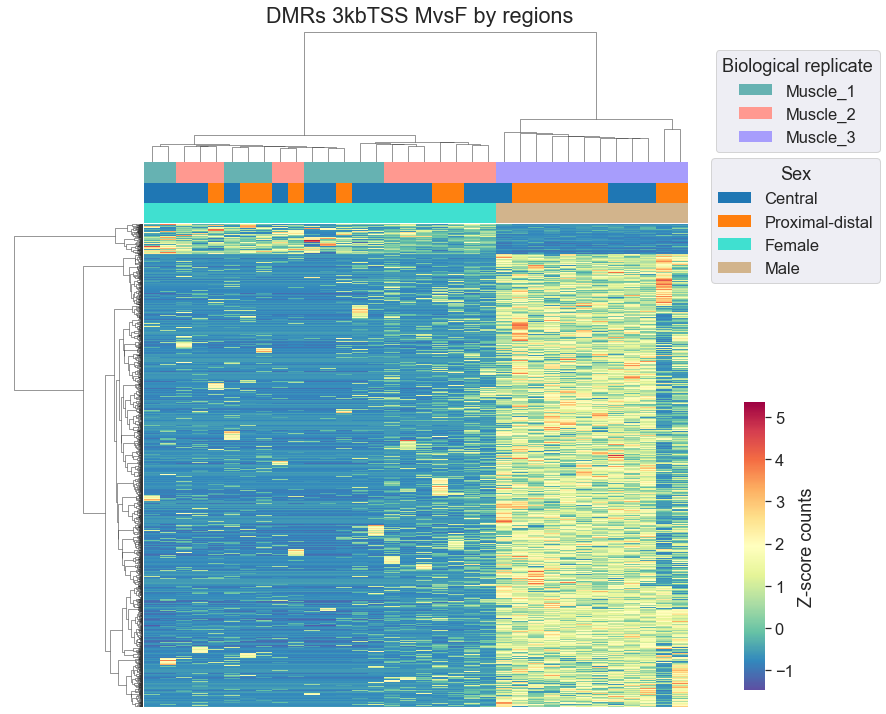

In [64]:
#assing replicates
samples=pd.Series(list(['Muscle_1']*10+['Muscle_2']*12+['Muscle_3']*12), index=list(np.arange(0,34)))
reference={'Muscle_1': '#66b2b2', 'Muscle_2': '#ff9990', 'Muscle_3': '#a79dfc'}
colors = samples.map(reference)

#assing region based on trasncriptomic data
samples2=pd.Series(list(['Central']*7+['Proximal-distal']*3+['Central']*8+['Proximal-distal']*4+['Proximal-distal']*4+['Central']*4+['Proximal-distal']*4), index=list(np.arange(0,34)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange', 'Unclassified': 'grey'}
colors2 = samples2.map(reference2)

#assing sex 
samples3=pd.Series(list(['Female']*22+['Male']*12), index=list(np.arange(0,34)))
reference3 = {'Male': 'tan', 'Female': 'turquoise'}
colors3 = samples3.map(reference3)

data_plot=zdf.reset_index(drop=True)
data_plot.columns = list(np.arange(0,34))

sns.set(font="sans-serif", font_scale=1.5)

g = sns.clustermap(data_plot, method='ward', cmap='Spectral_r', col_colors = [colors, colors2, colors3], yticklabels=False, xticklabels=False, cbar_kws={'label': "Z-score counts"})

# Turn off the clustering
# Add colored class labels 
#add title and adjust color bar location
g.fig.suptitle('DMRs 3kbTSS MvsF by regions', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# add legends
for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0);
l1 = g.ax_col_dendrogram.legend(title='Biological replicate', loc="upper right", ncol=1, bbox_to_anchor=(1.25, 0.95), bbox_transform=plt.gcf().transFigure)

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0);
l2 = g.ax_row_dendrogram.legend(title='Region', loc="upper right", ncol=1, bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

for label in samples3.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference3[label], label=label, linewidth=0);
l3 = g.ax_row_dendrogram.legend(title='Sex', loc="upper right", bbox_to_anchor=(1.25, 0.8),ncol=1,  bbox_transform=plt.gcf().transFigure)


plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
plt.savefig('DMRs_MvsF_3kbTSS.svg', format = 'svg', dpi=300, bbox_inches='tight')  
plt.show()
plt.close()

/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


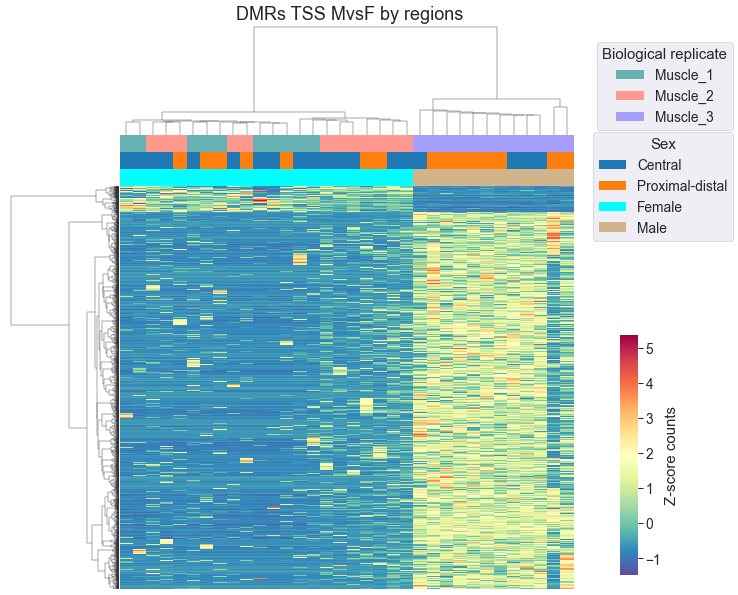

In [65]:
#assing replicates
samples=pd.Series(list(['Muscle_1']*10+['Muscle_2']*12+['Muscle_3']*12), index=list(np.arange(0,34)))
reference={'Muscle_1': '#66b2b2', 'Muscle_2': '#ff9990', 'Muscle_3': '#a79dfc'}
colors = samples.map(reference)

#assing region based on trasncriptomic data
samples2=pd.Series(list(['Central']*7+['Proximal-distal']*3+['Central']*8+['Proximal-distal']*4+['Proximal-distal']*4+['Central']*4+['Proximal-distal']*4), index=list(np.arange(0,34)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange', 'Unclassified': 'grey'}
colors2 = samples2.map(reference2)

#assing sex 
samples3=pd.Series(list(['Female']*22+['Male']*12), index=list(np.arange(0,34)))
reference3 = {'Male': 'tan', 'Female': 'cyan'}
colors3 = samples3.map(reference3)

data_plot=zdf.reset_index(drop=True)
data_plot.columns = list(np.arange(0,34))

# --- Figure settings for Illustrator-friendly PDF ---
plt.rcParams['pdf.fonttype'] = 42       # Illustrator-compatible fonts
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
mpl.rcParams["figure.dpi"] = 60         # lower DPI reduces embedded PNG size

sns.set(font="sans-serif", font_scale=1.5)

# --- Create clustermap ---
g = sns.clustermap(
    data_plot,
    method='ward',
    cmap='Spectral_r',
    col_colors=[colors, colors2, colors3],
    yticklabels=False,
    xticklabels=False,
    cbar_kws={'label': "Z-score counts"}
)

# --- Title and colorbar position ---
g.fig.suptitle('DMRs TSS MvsF by regions', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# --- Rasterize heatmap (main image) ---
for im in g.ax_heatmap.get_images():
    im.set_rasterized(True)

# Optional: rasterize col_colors if very large
for im in g.ax_col_colors.get_images():
    im.set_rasterized(True)

# --- Keep all text/vector elements ---
for ax in [g.ax_heatmap, g.ax_col_dendrogram, g.ax_row_dendrogram, g.cax]:
    for txt in ax.texts:
        txt.set_rasterized(False)

# --- Legends (vector) ---
for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='Biological replicate', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.95),
                                bbox_transform=plt.gcf().transFigure)

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0)
l2 = g.ax_row_dendrogram.legend(title='Region', loc="upper right", ncol=1,
                                bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

for label in samples3.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference3[label], label=label, linewidth=0)
l3 = g.ax_row_dendrogram.legend(title='Sex', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

# --- Save as PDF for Illustrator (smaller than SVG) ---
plt.savefig(
    'DMRs_MvsF_3kbTSS.pdf',
    dpi=60,                # reduces raster size inside PDF
    bbox_inches='tight',
    metadata={}            # remove metadata → smaller file
)
plt.show()
plt.close()

In [53]:
#Run GO
import gseapy
import scanpy as sc

In [54]:
#Available databases : ‘Human’, ‘Mouse’, ‘Yeast’, ‘Fly’, ‘Fish’, ‘Worm’ 
gene_set_names = gseapy.get_library_name(organism='Mouse')
print([name for name in gene_set_names if 'GO_Biological_Process' in name])

ConnectionError: HTTPConnectionPool(host='maayanlab.cloud', port=80): Max retries exceeded with url: /Enrichr/datasetStatistics (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7f99babf1400>: Failed to resolve 'maayanlab.cloud' ([Errno 8] nodename nor servname provided, or not known)"))

In [55]:
len([i.split("_")[1] for i in df_FC_TSS[df_FC_TSS['log2FC male vs female TSS'] <= -2].index])

839

In [56]:
enr_res = gseapy.enrichr(gene_list=[i.split("_")[1] for i in df_FC_TSS[df_FC_TSS['log2FC male vs female TSS'] <= -2].index], organism='Mouse', gene_sets='GO_Biological_Process_2025', cutoff = 0.05)
enr_res.results.head()

ConnectionError: HTTPConnectionPool(host='maayanlab.cloud', port=80): Max retries exceeded with url: /Enrichr/datasetStatistics (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7f998ed4acd0>: Failed to resolve 'maayanlab.cloud' ([Errno 8] nodename nor servname provided, or not known)"))

In [39]:
gseapy.dotplot(enr_res.res2d,title='1190 DMRs in F',cmap='viridis_r', size=5, figsize=(3,5))


ValueError: Warning: No enrich terms when cutoff = 0.05

In [168]:
len(gene_names[1])

3806

In [169]:
enr_res = gseapy.enrichr(gene_list=gene_names[1], organism='Mouse', gene_sets='GO_Biological_Process_2025', cutoff = 0.05)
enr_res.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Parallel Actin Filament Bundle Assembly (GO:00...,4/6,0.010220,0.999996,0,0,9.494108,43.515419,FSCN1;SPIRE2;USH1C;ESPN
1,GO_Biological_Process_2025,Positive Regulation of Peptide Secretion (GO:0...,4/8,0.035537,0.999996,0,0,4.746479,15.839819,FGB;TFR2;UCMA;ILDR1
2,GO_Biological_Process_2025,ISG15-protein Conjugation (GO:0032020),3/5,0.039960,0.999996,0,0,7.118534,22.920763,UBE2E1;UBE2E2;UBE2L6
3,GO_Biological_Process_2025,Antigen Processing and Presentation of Endogen...,3/6,0.069701,0.999996,0,0,4.745402,12.639605,SEC14L2;SEC14L3;IDE
4,GO_Biological_Process_2025,Regulation of High Voltage-Gated Calcium Chann...,3/6,0.069701,0.999996,0,0,4.745402,12.639605,CACNB3;CALM3;SRI


In [170]:
gseapy.dotplot(enr_res.res2d,title='3806 DMRs up in M',cmap='viridis_r', size=5, figsize=(3,5))


ValueError: Warning: No enrich terms when cutoff = 0.05

In [171]:
up_female=[i for i in gene_names[0] if 'Gm' not in i]
len(up_female)

866

### 3) Gene bodies

In [30]:
#calculte zscore
zdf = zscores(data_merged_GB_filtered)
szdf = scaledZscores(zdf)

/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


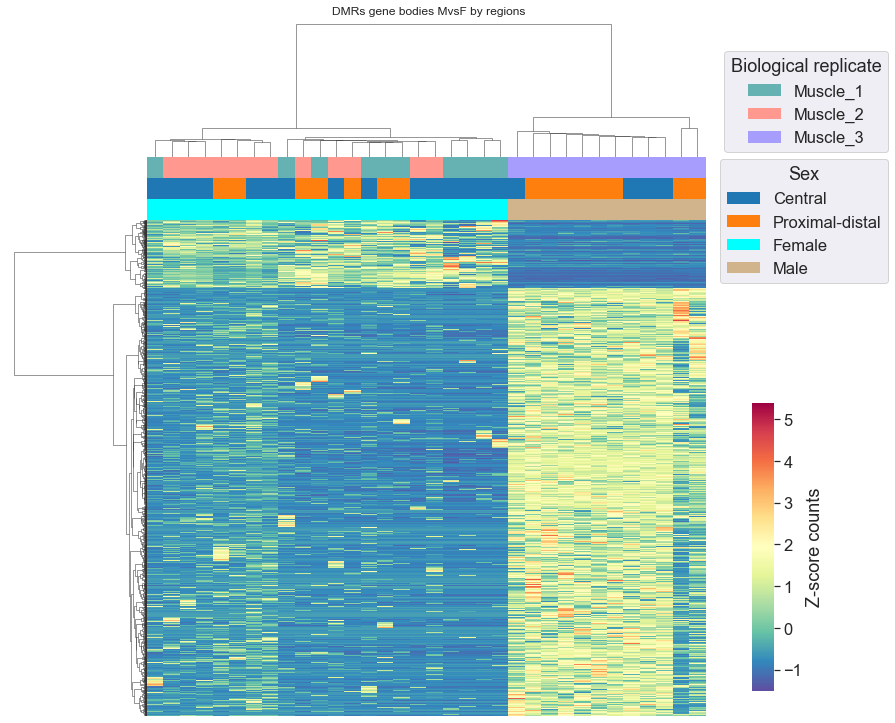

In [31]:
#assing replicates
samples=pd.Series(list(['Muscle_1']*10+['Muscle_2']*12+['Muscle_3']*12), index=list(np.arange(0,34)))
reference={'Muscle_1': '#66b2b2', 'Muscle_2': '#ff9990', 'Muscle_3': '#a79dfc'}
colors = samples.map(reference)

#assing region based on trasncriptomic data
samples2=pd.Series(list(['Central']*7+['Proximal-distal']*3+['Central']*8+['Proximal-distal']*4+['Proximal-distal']*4+['Central']*4+['Proximal-distal']*4), index=list(np.arange(0,34)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange', 'Unclassified': 'grey'}
colors2 = samples2.map(reference2)

#assing sex 
samples3=pd.Series(list(['Female']*22+['Male']*12), index=list(np.arange(0,34)))
reference3 = {'Male': 'tan', 'Female': 'cyan'}
colors3 = samples3.map(reference3)

data_plot=zdf.reset_index(drop=True)
data_plot.columns = list(np.arange(0,34))

# --- Figure settings for Illustrator-friendly PDF ---
plt.rcParams['pdf.fonttype'] = 42       # Illustrator-compatible fonts
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
mpl.rcParams["figure.dpi"] = 60         # lower DPI reduces embedded PNG size

sns.set(font="sans-serif", font_scale=1.5)

# --- Create clustermap ---
g = sns.clustermap(
    data_plot,
    method='ward',
    cmap='Spectral_r',
    col_colors=[colors, colors2, colors3],
    yticklabels=False,
    xticklabels=False,
    cbar_kws={'label': "Z-score counts"}
)

# --- Title and colorbar position ---
g.fig.suptitle('DMRs gene bodies MvsF by regions', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# --- Rasterize heatmap (main image) ---
for im in g.ax_heatmap.get_images():
    im.set_rasterized(True)

# Optional: rasterize col_colors if very large
for im in g.ax_col_colors.get_images():
    im.set_rasterized(True)

# --- Keep all text/vector elements ---
for ax in [g.ax_heatmap, g.ax_col_dendrogram, g.ax_row_dendrogram, g.cax]:
    for txt in ax.texts:
        txt.set_rasterized(False)

# --- Legends (vector) ---
for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='Biological replicate', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.95),
                                bbox_transform=plt.gcf().transFigure)

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0)
l2 = g.ax_row_dendrogram.legend(title='Region', loc="upper right", ncol=1,
                                bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

for label in samples3.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference3[label], label=label, linewidth=0)
l3 = g.ax_row_dendrogram.legend(title='Sex', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

# --- Save as PDF for Illustrator (smaller than SVG) ---
plt.savefig(
    'DMRs_MvsF_GeneBodies.pdf',
    dpi=60,                # reduces raster size inside PDF
    bbox_inches='tight',
    metadata={}            # remove metadata → smaller file
)
plt.show()
plt.close()

### 4) Regulatory regions

In [67]:
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path=''
file_names = ['M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_p0.05_MvsF_regulatory_v2.bed']
labels = ['DMRs_reg',]

#use accessData() function to obtain a dictonary with each dataset with labels as key
data = accessAnnBedData2(file_names, path, labels)
data['DMRs_reg'] = data['DMRs_reg'].drop(index=["X", "Y"])
data['DMRs_reg']

/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:42: DtypeWarning: Columns (0,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3,38,39,40,41,42,43,44,45,46], header=None)
/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/2445483224.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data['DMRs_reg'] = data['DMRs_reg'].drop(index=["X", "Y"])


4   \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   11.523931   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...    0.000000   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   44.175067   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  240.081886   

                                                                                                                                                        5   \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...   27.137438   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   35.119037   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  127.705589   

                                          

In [68]:
#rename sections by the same id as usplit DMRs file because
#access de data
#Create a variable list with the file names and one with the labels to use as dictionary keys
path=''
file_names = ['M1M2M3_1000bp0ovl_cpg_coverage_table_filtered_normal_DMR-ttest_p0.05_MvsF.bed']
labels = ['DMRs_all']

#use accessData() function to obtain a dictonary with each dataset with labels as key
data_all = accessBedData(file_names, path, labels)
data_all['DMRs_all']

/var/folders/mg/6wjwkry15y79vlj0f727ljh40000gq/T/ipykernel_480/3635111655.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(path+file, sep='\t', index_col=[0,1,2,3])


M1_s10    M1_s11     M1_s12     M1_s13  \
chr start   end     Lpnp1                                              
1   3052826 3053825 16      0.000000  0.000000   0.000000   1.978885   
    3235826 3236825 3       0.000000  0.000000   0.000000   0.000000   
    3418826 3419825 4       0.000000  7.981599   0.000000   0.000000   
    4523826 4524825 5       0.000000  0.000000   1.201205   0.000000   
    4590826 4591825 14     38.413102  0.000000  21.621697  16.820524   
...                              ...       ...        ...        ...   
Y   2360510 2361509 18      0.000000  0.000000   0.000000   0.000000   
    3843510 3844509 13      0.000000  0.000000   0.000000   0.000000   
    4247510 4248509 8       0.000000  0.000000   0.000000   0.000000   
    4248510 4249509 10      0.000000  0.000000   0.000000   0.000000   
    9624510 9625509 9       0.000000  0.000000   0.000000   0.000000   

                              M1_s24     M1_s25    M1_s27     M1_s35  \
chr start   end     Lpnp1                                              
1   3052826 3053825 16      0.000000   0.000000  0.000000   0.000000   
    3235826 3236825 3       0.000000   0.000000  0.000000   0.000000   
    3418826 3419825 4       0.000000   0.000000  0.000000   0.000000   
    4523826 4524825 5       0.000000   0.000000  0.000000   0.000000   
    4590826 4591825 14     42.156576  80.196818  7.130716  56.560629   
...                              ...        ...       ...        ...   
Y   2360510 2361509 18      0.000000   0.000000  0.000000   0.000000   
    3843510 3844509 13      0.000000   0.000000  0.000000   0.000000   
    4247510 4248509 8       0.000000   0.000000  0.000000   0.000000   
    4248510 4249509 10      0.000000   0.000000  0.000000   0.000000   
    9624510 9625509 9       0.000000   0.000000  0.000000   0.000000   

                             M1_s36     M1_s38  ...      M3_s3      M3_s4  \
chr start   end     Lpnp1                       ...                         
1   3052826 3053825 16     0.000000   0.000000  ...  15.140470   1.893172   
    3235826 3236825 3      0.000000   0.000000  ...   1.682274   5.679515   
    3418826 3419825 4      0.000000   1.919661  ...  11.775921  15.145373   
    4523826 4524825 5      0.000000   0.000000  ...   4.205686   0.946586   
    4590826 4591825 14     3.263199  17.276953  ...  74.020077  61.528077   
...                             ...        ...  ...        ...        ...   
Y   2360510 2361509 18     0.000000   0.000000  ...  21.869568  20.824888   
    3843510 3844509 13     0.000000   0.000000  ...  55.515058  30.290746   
    4247510 4248509 8      0.000000   0.000000  ...  41.215725  53.955390   
    4248510 4249509 10     0.000000   0.000000  ...  29.439804  44.489532   
    9624510 9625509 9      0.000000   0.000000  ...  43.739137  47.329290   

                               M3_s17      M3_s18      M3_s19     M3_s20  \
chr start   end     Lpnp1                                                  
1   3052826 3053825 16      14.181450   15.850242   12.403690  12.979227   
    3235826 3236825 3        4.171015    6.163983    1.653825   8.652818   
    3418826 3419825 4       21.689276   12.327966    4.134563   6.056973   
    4523826 4524825 5        8.342029    7.044552    8.269127   8.652818   
    4590826 4591825 14     100.938554  104.787713  100.883346  71.818392   
...                               ...         ...         ...        ...   
Y   2360510 2361509 18      22.523479   27.297639   16.538253  30.284864   
    3843510 3844509 13      23.357682   50.192434   41.345633  38.072401   
    4247510 4248509 8       37.539132   42.267313   42.172546  52.782192   
    4248510 4249509 10      25.860291   25.536501   25.634293  25.093173   
    9624510 9625509 9       44.212755   46.670158   37.211070  38.072401   

                               M3_s33     M3_s34     M3_s35     M3_s36  
chr start   end     Lpnp1                                               
1   3052826 3053825

In [69]:
data['DMRs_reg'].columns=data_all['DMRs_all'].columns
data['DMRs_reg']

M1_s10  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   11.523931   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...    0.000000   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   44.175067   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  240.081886   

                                                                                                                                                    M1_s11  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...   27.137438   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   35.119037   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  127.705589   

                                      

In [70]:
data_male = data['DMRs_reg'][['M3_s1', 'M3_s2', 'M3_s3', 'M3_s4', 'M3_s17', 'M3_s18','M3_s19', 'M3_s20',
    'M3_s33', 'M3_s34', 'M3_s35', 'M3_s36']]
data_male

M3_s1  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   15.976924   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    9.398190   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    6.578733   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    7.518552   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...   11.277828   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    8.458371   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...   23.495476   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    4.699095   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...  101.500456   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...   45.111314   

                                                                                                                                                     M3_s2  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    1.857532   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   52.010907   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...    0.000000   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    2.786299   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.928766   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.928766   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...  129.098502   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...   40.865713   

                                       

In [71]:
data_female = data['DMRs_reg'][['M1_s10', 'M1_s11', 'M1_s12', 'M1_s13','M1_s24', 'M1_s25', 'M1_s27','M1_s35', 'M1_s36', 'M1_s38',
    'M2_s8', 'M2_s9', 'M2_s10', 'M2_s11', 'M2_s22', 'M2_s23', 'M2_s24', 'M2_s25', 'M2_s36','M2_s37', 'M2_s38', 'M2_s39']]
data_female

M1_s10  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   11.523931   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...    0.000000   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   44.175067   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  240.081886   

                                                                                                                                                    M1_s11  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    0.000000   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...   27.137438   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...   35.119037   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  127.705589   

                                      

In [72]:
data_clusters=pd.DataFrame(index=data['DMRs_reg'].index)
data_clusters['male']=data_male.mean(axis=1)
data_clusters['female']=data_female.mean(axis=1)
data_clusters

male  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    8.905039   
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...   22.391162   
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...   12.283339   
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...   11.781131   
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...    4.604460   
...                                                                                                                                                    ...   
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    7.128783   
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...   22.899330   
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...   13.300020   
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...  107.614171   
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...   35.336767   

                                                                                                                                                    female  
0 1         2         3  38 39               40                41        42        43 44 45 46                                                              
1 3002826   3003825   5  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    2.343877  
  3003826   3004825   2  1  Regulatory_Build regulatory_region 3003401   3004000   .  .  .  ID=regulatory_region:ENSMUSR00000476168;bound_e...    5.188885  
  3025826   3026825   1  1  Regulatory_Build regulatory_region 3026804   3026999   .  .  .  ID=regulatory_region:ENSMUSR00000476169;bound_e...    0.000000  
  3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.089949  
  3149826   3150825   17 1  Regulatory_Build regulatory_region 3150235   3150396   .  .  .  ID=regulatory_region:ENSMUSR00000476173;bound_e...   12.809601  
...                                                                                                                                                    ...  
9 124080380 124081379 13 9  Regulatory_Build regulatory_region 124080001 124082000 .  .  .  ID=regulatory_region:ENSMUSR00000284635;bound_e...    0.000000  
  124137380 124138379 9  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000  
  124138380 124139379 1  9  Regulatory_Build regulatory_region 124137402 124139200 .  .  .  ID=regulatory_region:ENSMUSR00000758528;bound_e...    0.000000  
  124475380 124476379 14 9  Regulatory_Build regulatory_region 124475801 124476000 .  .  .  ID=regulatory_region:ENSMUSR00000758545;bound_e...  196.174609  
  124481380 124482379 1  9  Regulatory_Build regulatory_region 124477202 124481400 .  .  .  ID=regulatory_region:ENSMUSR00000284670;bound_e...  118.536882  

[85976 rows x 2 columns]

In [81]:
# Assuming your dataframe has columns ['male', 'female']
# Add a small value to avoid division by zero
epsilon = 0.1
df_FC_Reg = np.log2((data_clusters.iloc[:,0] + epsilon) / (data_clusters.iloc[:,1] + epsilon))

# Convert to dataframe and sort
df_FC_Reg = df_FC_Reg.to_frame(name="log2FC male vs female Reg")
df_FC_Reg = df_FC_Reg.sort_values(by="log2FC male vs female Reg", ascending=True)
#df_FC_Reg.to_excel('DMR male vs female regulatory.xlsx')
df_FC_Reg[-10:]

log2FC male vs female Reg
0  1         2         3  38 39               40                41        42        43 44 45 46                                                                           
6  19145210  19146209  43 6  Regulatory_Build regulatory_region 19146201  19146400  .  .  .  ID=regulatory_region:ENSMUSR00000696294;bound_e...                  10.267795
17 74329558  74330557  13 17 Regulatory_Build regulatory_region 74329401  74330200  .  .  .  ID=regulatory_region:ENSMUSR00000127110;bound_e...                  10.320480
11 58520580  58521579  15 11 Regulatory_Build regulatory_region 58521402  58521800  .  .  .  ID=regulatory_region:ENSMUSR00000043343;bound_e...                  10.322332
4  143241725 143242724 17 4  Regulatory_Build regulatory_region 143242401 143242600 .  .  .  ID=regulatory_region:ENSMUSR00000672902;bound_e...                  10.336695
12 115099067 115100066 10 12 Regulatory_Build regulatory_region 115099980 115100143 .  .  .  ID=regulatory_region:ENSMUSR00000540967;bound_e...                  10.430072
4  6158725   6159724   18 4  Regulatory_Build regulatory_region 6159402   6159908   .  .  .  ID=regulatory_region:ENSMUSR00000657005;bound_e...                  10.591738
2  47642001  47643000  52 2  Regulatory_Build regulatory_region 47642491  47642843  .  .  .  ID=regulatory_region:ENSMUSR00000624675;bound_e...                  10.737215
8  123429116 123430115 24 8  Regulatory_Build regulatory_region 123425683 123430626 .  .  .  ID=regulatory_region:ENSMUSR00000741556;bound_e...                  11.943992
   123428116 123429115 35 8  Regulatory_Build regulatory_region 123425683 123430626 .  .  .  ID=regulatory_region:ENSMUSR00000741556;bound_e...                  12.791126
   123427116 123428115 28 8  Regulatory_Build regulatory_region 123425683 123430626 .  .  .  ID=regulatory_region:ENSMUSR00000741556;bound_e...                  13.102594

In [74]:
df_FC_Reg.to_csv('DMR_male_vs_female_regulatory.csv', index=True)

In [75]:
for index in df_FC_Reg.index:
    if 'Myh' in index:
        print(df_FC_Reg.loc[index])

In [76]:
for index in df_FC_Reg.index:
    if 'ENSMUSG00000056328' in index[-1]:
        print(df_FC_Reg.loc[index])

In [77]:
df_FC_Reg_filtered=df_FC_Reg[(df_FC_Reg['log2FC male vs female Reg']>= 2) | (df_FC_Reg['log2FC male vs female Reg']<= -2)]
data_Reg_filtered=data['DMRs_reg'].loc[df_FC_Reg_filtered.index]
data_Reg_filtered


,,,,,,,,,,,,,M1_s10,M1_s11,M1_s12,M1_s13,M1_s24,M1_s25,M1_s27,M1_s35,M1_s36,M1_s38,...,M3_s3,M3_s4,M3_s17,M3_s18,M3_s19,M3_s20,M3_s33,M3_s34,M3_s35,M3_s36
0,1,2,3,38,39,40,41,42,43,44,45,46,,,,,,,,,,,,,,,,,,,,,
14,56997505,56998504,24,14,Regulatory_Build,regulatory_region,56998114,56998439,.,.,.,ID=regulatory_region:ENSMUSR00000561218;bound_end=56998439;bound_start=56998114;description=Open chromatin region;feature_type=Open chromatin,184.382889,0.000000,219.820588,24.736065,54.611927,81.097906,90.916633,133.787642,150.107131,54.710351,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,35643580,35644579,4,11,Regulatory_Build,regulatory_region,35643320,35643654,.,.,.,ID=regulatory_region:ENSMUSR00000514667;bound_end=35643654;bound_start=35643320;description=Open chromatin region;feature_type=Open chromatin,0.000000,3.192640,60.060270,107.849243,9.581040,28.834811,27.631526,45.683585,39.158382,138.215624,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,81965210,81966209,33,6,Regulatory_Build,regulatory_region,81964600,81966401,.,.,.,ID=regulatory_region:ENSMUSR00000229877;bound_end=81966799;bound_start=81964402;description=Predicted promoter;feature_type=Promoter,124.842581,692.802821,400.001398,270.117829,206.950462,90.108784,326.230272,366.556385,356.776370,134.376301,...,1.682274,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.452992,2.886823
15,60141433,60142432,3,15,Regulatory_Build,regulatory_region,60141459,60142290,.,.,.,ID=regulatory_region:ENSMUSR00000572667;bound_end=60142290;bound_start=60141397;description=Transcription factor binding site;feature_type=TF binding site,1525.000142,3419.317149,3684.096958,1986.800738,1146.850477,3088.929132,2286.285926,2501.720135,2934.703193,2465.805124,...,4.205686,8.519272,5.005218,0.880569,6.615301,9.518100,1.821332,10.789262,15.450145,3.849097
11,31681580,31682579,1,11,Regulatory_Build,regulatory_region,31681801,31682000,.,.,.,ID=regulatory_region:ENSMUSR00000514008;bound_end=31682000;bound_start=31681801;description=Predicted promoter flanking region;feature_type=Promoter Flanking Region,0.000000,173.998865,57.657859,19.788852,16.287768,39.647865,9.804735,0.000000,0.000000,30.714583,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,6158725,6159724,18,4,Regulatory_Build,regulatory_region,6159402,6159908,.,.,.,ID=regulatory_region:ENSMUSR00000657005;bound_end=6159908;bound_start=6159402;description=Predicted promoter flanking region;feature_type=Promoter Flanking Region,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,177.479958,113.590296,140.980294,134.727059,138.094416,147.963193,132.957264,137.563090,155.410280,161.662070
2,47642001,47643000,52,2,Regulatory_Build,regulatory_region,47642491,47642843,.,.,.,ID=regulatory_region:ENSMUSR00000624675;bound_end=47642843;bound_start=47642491;description=Open chromatin region;feature_type=Open chromatin,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.777606,323.732343,120.959424,135.607628,119.075424,142.771502,142.063926,94.406042,101.789190,62.547825
8,123429116,123430115,24,8,Regulatory_Build,regulatory_region,123425683,123430626,.,.,.,ID=regulatory_region:ENSMUSR00000741556;bound_end=123430626;bound_start=123425683;description=Transcription factor binding site;feature_type=TF binding site,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,256.546859,661.663473,395.412186,353.988744,291.073259,302.848642,295.966513,372.229537,328.997202,282.908622


In [78]:
#calculte zscore
zdf = zscores(data_Reg_filtered)
szdf = scaledZscores(zdf)

/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/claramartinezmir/venv/base-env2/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


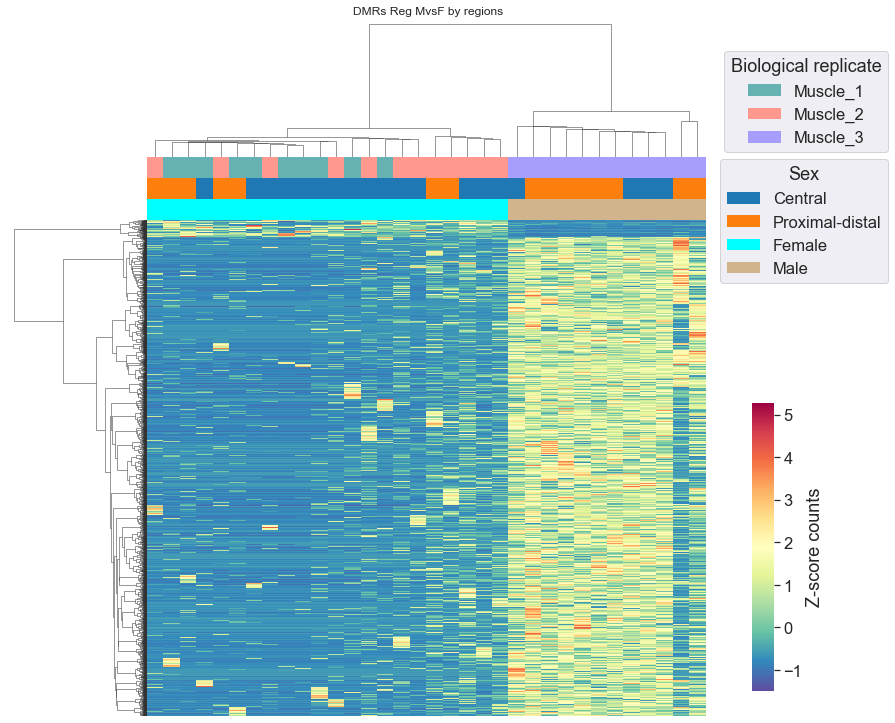

In [28]:
#assing replicates
samples=pd.Series(list(['Muscle_1']*10+['Muscle_2']*12+['Muscle_3']*12), index=list(np.arange(0,34)))
reference={'Muscle_1': '#66b2b2', 'Muscle_2': '#ff9990', 'Muscle_3': '#a79dfc'}
colors = samples.map(reference)

#assing region based on trasncriptomic data
samples2=pd.Series(list(['Central']*7+['Proximal-distal']*3+['Central']*8+['Proximal-distal']*4+['Proximal-distal']*4+['Central']*4+['Proximal-distal']*4), index=list(np.arange(0,34)))
reference2 = {'Central': 'tab:blue', 'Proximal-distal': 'tab:orange', 'Unclassified': 'grey'}
colors2 = samples2.map(reference2)

#assing sex 
samples3=pd.Series(list(['Female']*22+['Male']*12), index=list(np.arange(0,34)))
reference3 = {'Male': 'tan', 'Female': 'cyan'}
colors3 = samples3.map(reference3)

data_plot=zdf.reset_index(drop=True)
data_plot.columns = list(np.arange(0,34))

# --- Figure settings for Illustrator-friendly PDF ---
plt.rcParams['pdf.fonttype'] = 42       # Illustrator-compatible fonts
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 7
mpl.rcParams["figure.dpi"] = 60         # lower DPI reduces embedded PNG size

sns.set(font="sans-serif", font_scale=1.5)

# --- Create clustermap ---
g = sns.clustermap(
    data_plot,
    method='ward',
    cmap='Spectral_r',
    col_colors=[colors, colors2, colors3],
    yticklabels=False,
    xticklabels=False,
    cbar_kws={'label': "Z-score counts"}
)

# --- Title and colorbar position ---
g.fig.suptitle('DMRs Reg MvsF by regions', y=1, x=0.6)
g.ax_cbar.set_position((1.05, 0.05, .03, 0.4))

# --- Rasterize heatmap (main image) ---
for im in g.ax_heatmap.get_images():
    im.set_rasterized(True)

# Optional: rasterize col_colors if very large
for im in g.ax_col_colors.get_images():
    im.set_rasterized(True)

# --- Keep all text/vector elements ---
for ax in [g.ax_heatmap, g.ax_col_dendrogram, g.ax_row_dendrogram, g.cax]:
    for txt in ax.texts:
        txt.set_rasterized(False)

# --- Legends (vector) ---
for label in samples.unique():
    g.ax_col_dendrogram.bar(0, 0, color=reference[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='Biological replicate', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.95),
                                bbox_transform=plt.gcf().transFigure)

for label in samples2.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference2[label], label=label, linewidth=0)
l2 = g.ax_row_dendrogram.legend(title='Region', loc="upper right", ncol=1,
                                bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

for label in samples3.unique():
    g.ax_row_dendrogram.bar(0, 0, color=reference3[label], label=label, linewidth=0)
l3 = g.ax_row_dendrogram.legend(title='Sex', loc="upper right",
                                ncol=1, bbox_to_anchor=(1.25, 0.8), bbox_transform=plt.gcf().transFigure)

# --- Save as PDF for Illustrator (smaller than SVG) ---
plt.savefig(
    'DMRs_MvsF_regulatory.pdf',
    dpi=60,                # reduces raster size inside PDF
    bbox_inches='tight',
    metadata={}            # remove metadata → smaller file
)
plt.show()
plt.close()

In [71]:
feature_type=[]
for type in data_Reg_filtered.index.get_level_values(46):
    feature_type.append(type.split(';')[-1])
types_features=set(feature_type)
dic_types={}
for type in types_features:
    dic_types[type]=feature_type.count(type)
dic_types
    

{'feature_type=CTCF Binding Site': 8334,
 'feature_type=Open chromatin': 4941,
 'feature_type=Promoter Flanking Region': 11462,
 'feature_type=Promoter': 2900,
 'feature_type=TF binding site': 1479,
 'feature_type=Enhancer': 5947}

In [123]:
types_features=set(feature_type)
types_features

{'feature_type=CTCF Binding Site',
 'feature_type=Enhancer',
 'feature_type=Open chromatin',
 'feature_type=Promoter',
 'feature_type=Promoter Flanking Region',
 'feature_type=TF binding site'}

In [124]:
data['DMRs_reg']['Feature_type']=feature_type

In [125]:
#select gene ids
gene_id=[]
for type in data['DMRs_reg'].index.get_level_values(46):
    gene_id.append(type.split(';')[0].split(':')[-1])
data['DMRs_reg']['gene_id']=gene_id
data['DMRs_reg']

M1_s10  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  4759826   4760825   8  1  Regulatory_Build regulatory_region 4760401   4760601   .  .  .  ID=regulatory_region:ENSMUSR00000476234;bound_e...    0.000000   
  4865826   4866825   1  1  Regulatory_Build regulatory_region 4866001   4866400   .  .  .  ID=regulatory_region:ENSMUSR00000476251;bound_e...    0.000000   
  6206826   6207825   5  1  Regulatory_Build regulatory_region 6207201   6207600   .  .  .  ID=regulatory_region:ENSMUSR00000476312;bound_e...    0.000000   
  8844826   8845825   4  1  Regulatory_Build regulatory_region 8845445   8845634   .  .  .  ID=regulatory_region:ENSMUSR00000000303;bound_e...    0.000000   
...                                                                                                                                                    ...   
X 168796057 168797056 41 X  Regulatory_Build regulatory_region 168794600 168798400 .  .  .  ID=regulatory_region:ENSMUSR00000292651;bound_e...  699.118453   
  169302057 169303056 21 X  Regulatory_Build regulatory_region 169302401 169302800 .  .  .  ID=regulatory_region:ENSMUSR00000292699;bound_e...  134.445856   
  169319057 169320056 15 X  Regulatory_Build regulatory_region 169318800 169321201 .  .  .  ID=regulatory_region:ENSMUSR00000292701;bound_e...  161.335028   
  169320057 169321056 80 X  Regulatory_Build regulatory_region 169318800 169321201 .  .  .  ID=regulatory_region:ENSMUSR00000292701;bound_e...  353.400537   
  169880057 169881056 19 X  Regulatory_Build regulatory_region 169879200 169881801 .  .  .  ID=regulatory_region:ENSMUSR00000292728;bound_e...    0.000000   

                                                                                                                                                    M1_s11  \
0 1         2         3  38 39               40                41        42        43 44 45 46                                                               
1 3052826   3053825   16 1  Regulatory_Build regulatory_region 3052529   3052929   .  .  .  ID=regulatory_region:ENSMUSR00000000003;bound_e...    0.000000   
  4759826   4760825   8  1  Regulatory_Build regulatory_region 4760401   4760601   .  .  .  ID=regulatory_region:ENSMUSR00000476234;bound_e...    0.000000   
  4865826   4866825   1  1  Regulatory_Build regulatory_region 4866001   4866400   .  .  .  ID=regulatory_region:ENSMUSR00000476251;bound_e...    0.000000   
  6206826   6207825   5  1  Regulatory_Build regulatory_region 6207201   6207600   .  .  .  ID=regulatory_region:ENSMUSR00000476312;bound_e...    0.000000   
  8844826   8845825   4  1  Regulatory_Build regulatory_region 8845445   8845634   .  .  .  ID=regulatory_region:ENSMUSR00000000303;bound_e...    0.000000   
...                                                                                                                                                    ...   
X 168796057 168797056 41 X  Regulatory_Build regulatory_region 168794600 168798400 .  .  .  ID=regulatory_region:ENSMUSR00000292651;bound_e...  122.916630   
  169302057 169303056 21 X  Regulatory_Build regulatory_region 169302401 169302800 .  .  .  ID=regulatory_region:ENSMUSR00000292699;bound_e...   92.586552   
  169319057 169320056 15 X  Regulatory_Build regulatory_region 169318800 169321201 .  .  .  ID=regulatory_region:ENSMUSR00000292701;bound_e...    6.385279   
  169320057 169321056 80 X  Regulatory_Build regulatory_region 169318800 169321201 .  .  .  ID=regulatory_region:ENSMUSR00000292701;bound_e...  213.906862   
  169880057 169881056 19 X  Regulatory_Build regulatory_region 169879200 169881801 .  .  .  ID=regulatory_region:ENSMUSR00000292728;bound_e...   12.770559   

                                      

In [126]:
#Find H19: ENSMUSG00000000031
for gene in gene_id:
    if 'ENSG00000288237' in gene:
        print('H19 found')
    